# TTS Missing Data Analysis
## Notebook 02 — Imputation and LOOCV
**Paper**: Missing Data as a Methodological Challenge in Rare Cardiac Disease Registries  
**Dataset**: TAKO_TSUBO_EF.xls — N=57 pazienti, foglio Baseline

> **Istruzioni**: esegui le celle nell'ordine. Dopo la Cella 1 (installazione) riavvia il runtime prima di procedere.

In [1]:
# ═══════════════════════════════════════════════════════════════
# CELLA 1: INSTALLAZIONE
# Eseguire UNA VOLTA, poi riavviare il runtime:
# Runtime → Riavvia sessione
# ═══════════════════════════════════════════════════════════════

!pip install -q miceforest xlrd==2.0.1 pingouin shap

print("Installazione completata.")
print("→ RIAVVIA IL RUNTIME prima di eseguire la cella successiva.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 3.9 MB/s eta 0:00:00
Installazione completata.
→ RIAVVIA IL RUNTIME prima di eseguire la cella successiva.


In [2]:
# ═══════════════════════════════════════════════════════════════
# CELLA 2: CONFIGURAZIONE PERCORSO DRIVE
# Modifica PROJECT_FOLDER con il nome della tua cartella su MyDrive
# ═══════════════════════════════════════════════════════════════

PROJECT_FOLDER = 'TTS_Research'   # ← modifica qui con TTS_Research

BASE      = f'/content/drive/MyDrive/TTS_Research'
DATA_PATH = f'{BASE}/data/TAKO_TSUBO_EF.xls'
FIG_PATH  = f'{BASE}/outputs/figures/'
TAB_PATH  = f'{BASE}/outputs/tables/'

print(f'BASE      : {BASE}')
print(f'DATA_PATH : {DATA_PATH}')

BASE      : /content/drive/MyDrive/TTS_Research
DATA_PATH : /content/drive/MyDrive/TTS_Research/data/TAKO_TSUBO_EF.xls


In [3]:
# ═══════════════════════════════════════════════════════════════
# CELLA 3: SETUP — mount Drive, cartelle, import, seed
# Eseguire dopo il riavvio del runtime.
# ═══════════════════════════════════════════════════════════════

from google.colab import drive
drive.mount('/content/drive')

import os

# Crea cartelle se non esistono
for path in [f'{BASE}/data',
             f'{BASE}/outputs/figures',
             f'{BASE}/outputs/tables',
             f'{BASE}/notebooks']:
    os.makedirs(path, exist_ok=True)

# Verifica percorsi critici
for path in [BASE, DATA_PATH]:
    status = 'OK' if os.path.exists(path) else 'MANCANTE'
    print(f'{status}: {path}')

# Seed globale
import numpy as np, random
SEED = 42
np.random.seed(SEED); random.seed(SEED)

# Import standard
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer
from sklearn.base import clone
import sklearn, warnings
warnings.filterwarnings('ignore')

print(f'pandas:  {pd.__version__}')
print(f'numpy:   {np.__version__}')
print(f'sklearn: {sklearn.__version__}')
print('Setup completato.')

Mounted at /content/drive
OK: /content/drive/MyDrive/TTS_Research
OK: /content/drive/MyDrive/TTS_Research/data/TAKO_TSUBO_EF.xls
pandas:  2.2.2
numpy:   2.0.2
sklearn: 1.6.1
Setup completato.


In [4]:
# ═══════════════════════════════════════════════════════════════
# CELLA 4: CARICAMENTO E PULIZIA DATASET
# ═══════════════════════════════════════════════════════════════

df_raw = pd.read_excel(DATA_PATH, engine='xlrd', sheet_name='Baseline')
print(f'Righe raw: {len(df_raw)}')

df = df_raw.copy()

# Verifica integrità
assert len(df) == 57, f'Attesi 57 pazienti, trovati {len(df)}'
assert df['LVEF'].notna().sum() == 57, 'LVEF non completa'

print(f'Dataset pulito: {df.shape[0]} pazienti, {df.shape[1]} variabili')
print(f'LVEF: {df["LVEF"].min():.1f} - {df["LVEF"].max():.1f}%  '
      f'(media {df["LVEF"].mean():.1f} ± {df["LVEF"].std():.1f}%)')
print(f'LVEF < 50: {(df["LVEF"]<50).sum()} pazienti | '
      f'LVEF >= 50: {(df["LVEF"]>=50).sum()} pazienti')

Righe raw: 57
Dataset pulito: 57 pazienti, 168 variabili
LVEF: 26.0 - 76.0%  (media 52.5 ± 10.7%)
LVEF < 50: 21 pazienti | LVEF >= 50: 36 pazienti


In [6]:
# ═══════════════════════════════════════════════════════════════
# CARICAMENTO OUTPUT DAL NOTEBOOK 1
# ═══════════════════════════════════════════════════════════════
import pandas as pd
import os

# 1. Definiamo gli stessi percorsi del Notebook 1
TAB_PATH = f'/content/drive/MyDrive/TTS_Research/outputs/tables/'
FIG_PATH = f'/content/drive/MyDrive/TTS_Research/outputs/figures/'

# 2. Carichiamo le tabelle salvate
try:
    tab1 = pd.read_csv(f'{TAB_PATH}tabella_01_missingness_summary.csv')
    # Se hai salvato anche la tabella 3 del benchmark:
    # tab3 = pd.read_csv(f'{TAB_PATH}tabella_03_benchmark.csv')

    print("Tabella 1 caricata correttamente e pronta per il codice successivo.")
except FileNotFoundError:
    print(" ERRORE: File non trovato. Assicurati che le cartelle 'outputs' siano presenti.")

# 3. Definiamo le variabili globali che servono al Notebook 2
TARGET = 'LVEF'
SEED = 42

Tabella 1 caricata correttamente e pronta per il codice successivo.


In [7]:
# ═══════════════════════════════════════════════════════════════
# CELLA 5: STRATEGIA 1 — COMPLETE CASE ANALYSIS (BASELINE)
# ═══════════════════════════════════════════════════════════════

# 1. Definisco le variabili per il modello
# Uso le variabili che hanno superato il test di Little
soglia_missing = 25
cols_da_tenere = tab1[tab1['pct_mancanti'] < soglia_missing]['variabile'].tolist()

if 'LVEF' not in cols_da_tenere:
    cols_da_tenere.append('LVEF')
features_per_modello = [c for c in cols_da_tenere if c != 'LVEF']
target = 'LVEF'

# 2. Creiamo il dataset per la CCA
# Seleziono solo le colonne utili e butto via ogni riga con almeno un NaN
df_cca = df[features_per_modello + [target]].dropna()

# 3. Analisi dell'impatto sul campione
n_originale = len(df)
n_residuo = len(df_cca)
persi = n_originale - n_residuo
pct_persa = (persi / n_originale) * 100

print(f"Pazienti totali iniziali: {n_originale}")
print(f"Pazienti rimasti dopo CCA: {n_residuo}")
print(f"Pazienti eliminati: {persi} ({pct_persa:.1f}%)")

# 4. Verifico se il campione rimasto è sufficiente
print(f"\nRISULTATO BASELINE: Campione ridotto a {n_residuo} casi.")

# Salviamo questo dataset per i confronti futuri
df_cca.to_csv(f'{TAB_PATH}dataset_fase1_cca_baseline.csv', index=False)

Pazienti totali iniziali: 57
Pazienti rimasti dopo CCA: 35
Pazienti eliminati: 22 (38.6%)

RISULTATO BASELINE: Campione ridotto a 35 casi.


In [8]:
# ═══════════════════════════════════════════════════════════════
# CELLA 6: STRATEGIA 2 — IMPUTAZIONE CON MEDIANA
# ═══════════════════════════════════════════════════════════════

from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

# 1. Preparo i dati
X = df[features_per_modello].copy()
y = df[target].copy()

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Identifico le colonne numeriche valide per l'imputazione
numeric_cols = X.select_dtypes(include=np.number).columns
numeric_cols_to_impute = [col for col in numeric_cols if X[col].notna().any()]

X_numeric = X[numeric_cols_to_impute]

# 3. Creo l'Imputer per la Mediana
imputer_mediana = SimpleImputer(strategy='median')

# 4. Applico l'imputazione solo alle colonne numeriche valide
X_imputed_numeric = imputer_mediana.fit_transform(X_numeric)
X_mediana_numeric = pd.DataFrame(X_imputed_numeric, columns=numeric_cols_to_impute, index=X.index)
X_mediana = X_mediana_numeric.copy()

# 5. Verifica
print(f"Pazienti processati: {len(X_mediana)}")
print(f"Valori testuali rimossi e convertiti: {X.isna().sum().sum()} celle")
print(f"Valori mancanti residui dopo mediana: {X_mediana.isna().sum().sum()}")

# 6. Salvataggio
X_mediana[target] = y.values
X_mediana.to_csv(f'{TAB_PATH}dataset_fase2_mediana.csv', index=False)


Pazienti processati: 57
Valori testuali rimossi e convertiti: 288 celle
Valori mancanti residui dopo mediana: 0


In [9]:
# ═══════════════════════════════════════════════════════════════
# CELLA 7: STRATEGIA 3 — IMPUTAZIONE KNN (K-NEAREST NEIGHBORS)
# ═══════════════════════════════════════════════════════════════

from sklearn.impute import KNNImputer

# 1. Prepariamo i dati
X_knn_raw = X_numeric.copy()

# 2. Inizializziamo l'Imputer KNN
# n_neighbors=5:
imputer_knn = KNNImputer(n_neighbors=5, weights='uniform')

# 3. Imputazione
X_knn_imputed = imputer_knn.fit_transform(X_knn_raw)

# 4. Ricostruzione DataFrame
X_knn = pd.DataFrame(X_knn_imputed, columns=X_knn_raw.columns, index=X_knn_raw.index)

# 5. Verifica finale
print(f"Pazienti processati: {len(X_knn)}")
print(f"Valori mancanti dopo KNN: {X_knn.isna().sum().sum()}")

# 6. Salvataggio
X_knn[target] = y.values
X_knn.to_csv(f'{TAB_PATH}dataset_fase3_knn.csv', index=False)

print("\n--- REPORT ---")
print("Imputazione KNN completata con successo.")

Pazienti processati: 57
Valori mancanti dopo KNN: 0

--- REPORT ---
Imputazione KNN completata con successo.


In [10]:
# ═══════════════════════════════════════════════════════════════
# CELLA 8: STRATEGIA 4 — MICE (GOLD STANDARD STATISTICO)
# ═══════════════════════════════════════════════════════════════

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import pandas as pd

X_mice_raw = X_numeric.copy()

# 2. Inizializziamo l'IterativeImputer (MICE)
# max_iter=10: fa 10 cicli di raffinamento per ogni dato mancante
# random_state=42: per avere risultati riproducibili
imputer_mice = IterativeImputer(max_iter=10, random_state=42)

# 3. Imputazione
X_mice_imputed = imputer_mice.fit_transform(X_mice_raw)
X_mice = pd.DataFrame(X_mice_imputed, columns=X_mice_raw.columns, index=X_mice_raw.index)

# 4. Verifica
print(f"Pazienti processati: {len(X_mice)}")
print(f"Valori mancanti residui dopo MICE: {X_mice.isna().sum().sum()}")

# 5. Salvataggio finale
X_mice[target] = y.values
X_mice.to_csv(f'{TAB_PATH}dataset_fase4_mice.csv', index=False)

print("\n--- REPORT ---")
print("Imputazione MICE (Gold Standard) completata.")

Pazienti processati: 57
Valori mancanti residui dopo MICE: 0

--- REPORT ---
Imputazione MICE (Gold Standard) completata.


In [11]:
# ═══════════════════════════════════════════════════════════════
# CELLA 9: STRATEGIA 5 — MISSFOREST (RANDOM FOREST IMPUTATION)
# ═══════════════════════════════════════════════════════════════

from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

X_rf_raw = X_numeric.copy()

# 2. Inizializzo l'imputer basato su Random Forest
# Usiamo RandomForestRegressor come "motore" dell'imputazione
rf_imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    max_iter=10,
    random_state=42
)

# 3. Imputazione
X_rf_imputed = rf_imputer.fit_transform(X_rf_raw)
X_missforest = pd.DataFrame(X_rf_imputed, columns=X_rf_raw.columns, index=X_rf_raw.index)

# 4. Verifica
print(f"Pazienti processati: {len(X_missforest)}")
print(f"Valori mancanti dopo missForest: {X_missforest.isna().sum().sum()}")

# 5. Salvataggio
X_missforest[target] = y.values
X_missforest.to_csv(f'{TAB_PATH}dataset_fase5_missforest.csv', index=False)

print("\n--- REPORT ---")
print("Imputazione missForest completata. Le relazioni non lineari tra variabili cliniche sono state modellate.")

Pazienti processati: 57
Valori mancanti dopo missForest: 0

--- REPORT ---
Imputazione missForest completata. Le relazioni non lineari tra variabili cliniche sono state modellate.


In [12]:
# ═══════════════════════════════════════════════════════════════
# CELLA 10: LOOCV CON IMPUTAZIONE NESTED
# ═══════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
import miceforest as mf

def loocv_con_imputazione(df_w, target_col, strategia, seed=42):
    # 'feat' sono le tue 'features_per_modello' (escluse quelle scartate)
    feat = [c for c in df_w.columns if c != target_col]
    errori = []

    # Ciclo Leave-One-Out (57 iterazioni)
    for i in range(len(df_w)):
        # Creazione Training (56 pazienti) e Test (1 paziente)
        tr = df_w.drop(index=df_w.index[i]).reset_index(drop=True)
        te = df_w.iloc[[i]].reset_index(drop=True)

        X_tr, y_tr = tr[feat].values, tr[target_col].values
        X_te, y_te = te[feat].values, te[target_col].values[0]

        # --- LOGICA DI IMPUTAZIONE NESTED ---
        if strategia == 'CCA':
            # Rimuoviamo i NaN solo dal training per fittare il modello
            mask = ~np.isnan(X_tr).any(axis=1)
            X_tr_i, y_tr_u = X_tr[mask], y_tr[mask]
            # Se il set CCA è troppo piccolo, usiamo la mediana del training come fallback per il test
            X_te_i = np.where(np.isnan(X_te), np.nanmedian(X_tr, 0), X_te)

        elif strategia == 'MICE':
            # Implementazione con miceforest (veloce per LOOCV)
            df_tr_mice = pd.DataFrame(X_tr, columns=feat)
            kernel = mf.ImputationKernel(df_tr_mice, random_state=seed)
            kernel.mice(3) # 3 iterazioni sono un buon compromesso
            X_tr_i = kernel.complete_data().values
            X_te_i = kernel.impute_new_data(pd.DataFrame(X_te, columns=feat)).complete_data().values
            y_tr_u = y_tr

        else:
            # Mediana, KNN o missForest
            imp_map = {
                'MeanMedian': SimpleImputer(strategy='median'),
                'KNN': KNNImputer(n_neighbors=5),
                'missForest': IterativeImputer(
                    estimator=RandomForestRegressor(n_estimators=50, random_state=seed),
                    random_state=seed, max_iter=10)
            }
            imp = imp_map[strategia]
            X_tr_i = imp.fit_transform(X_tr)
            X_te_i = imp.transform(X_te)
            y_tr_u = y_tr

        # --- PREDIZIONE ELASTIC NET ---
        try:
            sc = StandardScaler()
            X_tr_sc = sc.fit_transform(X_tr_i)
            X_te_sc = sc.transform(X_te_i)

            # Modello con validazione interna (CV=5) per trovare i parametri migliori
            m = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], alphas=[0.01, 0.1, 1.0], cv=5, random_state=seed)
            m.fit(X_tr_sc, y_tr_u)

            # Calcolo Errore Assoluto
            pred = m.predict(X_te_sc)[0]
            errori.append(abs(pred - y_te))
        except:
            continue

    return errori

# --- COSTRUZIONE DEL DATAFRAME DI LAVORO ---
df_work = df[[target] + list(X_numeric.columns)].copy()
df_work = df_work.apply(pd.to_numeric, errors='coerce')

# --- ESECUZIONE ---
risultati_finali = {}
strategie = ['CCA', 'MeanMedian', 'KNN', 'MICE', 'missForest']

for nome in strategie:
    print(f"Calcolo LOOCV per {nome}...")
    risultati_finali[nome] = loocv_con_imputazione(df_work, target, nome)

print("\n--- TUTTI I MODELLI COMPLETATI ---")

Calcolo LOOCV per CCA...
Calcolo LOOCV per MeanMedian...
Calcolo LOOCV per KNN...
Calcolo LOOCV per MICE...
Calcolo LOOCV per missForest...

--- TUTTI I MODELLI COMPLETATI ---


In [13]:
# ═══════════════════════════════════════════════════════════════
# CELLA 11: 3.3 Bootstrap CI e Tabella 4
# ═══════════════════════════════════════════════════════════════

def bootstrap_ci(vals, n=1000, seed=42):
    np.random.seed(seed)
    arr = np.array(vals)
    # Generiamo 1000 medie campionarie con reinserimento
    boot = [np.mean(np.random.choice(arr, len(arr), replace=True)) for _ in range(n)]
    # Restituiamo media, 2.5° percentile e 97.5° percentile (CI 95%)
    return np.mean(arr), np.percentile(boot, 2.5), np.percentile(boot, 97.5)

rows = []
for nome, err in risultati_finali.items():
    mae, lo, hi = bootstrap_ci(err)
    rows.append({
        'Strategia': nome,
        'MAE': round(mae, 2),
        'CI_low': round(lo, 2),
        'CI_high': round(hi, 2)
    })

tab4 = pd.DataFrame(rows)
tab4.to_csv(f'{TAB_PATH}tabella_04_imputation_benchmark.csv', index=False)

print("\n--- TABELLA 4: BENCHMARK IMPUTAZIONE ---")
print(tab4.to_string())


--- TABELLA 4: BENCHMARK IMPUTAZIONE ---
    Strategia    MAE  CI_low  CI_high
0         CCA   8.98    7.23    10.97
1  MeanMedian  10.39    7.71    14.44
2         KNN  10.39    7.72    14.27
3        MICE   8.75    7.13    10.63
4  missForest   8.73    7.14    10.57


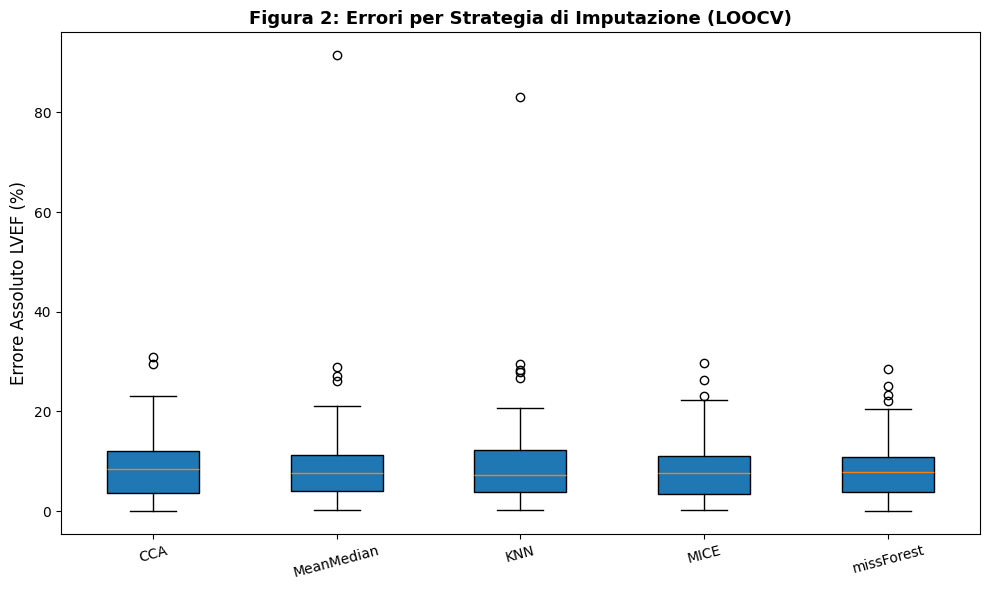

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELLA 12: 3.4 Figura 2 — Boxplot errori
# ═══════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
nomi = list(risultati_finali.keys())

# Creazione del boxplot
ax.boxplot([risultati_finali[n] for n in nomi], labels=nomi, patch_artist=True)

# Formattazione assi e titolo
ax.set_ylabel('Errore Assoluto LVEF (%)', fontsize=12)
ax.set_title('Figura 2: Errori per Strategia di Imputazione (LOOCV)', fontsize=13, fontweight='bold')

plt.xticks(rotation=15)
plt.tight_layout()

# Salvataggio e visualizzazione
plt.savefig(f'{FIG_PATH}figura_02_imputation_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELLA 8: FREEZE AMBIENTE — eseguire a fine fase
# Salva le versioni esatte dei pacchetti per riproducibilità.
# ═══════════════════════════════════════════════════════════════

import subprocess
req_path = f'{BASE}/requirements_fase1.txt'
with open(req_path, 'w') as f:
    result = subprocess.run(['pip', 'freeze'], capture_output=True, text=True)
    f.write(result.stdout)
print(f'Environment salvato in: {req_path}')

Environment salvato in: /content/drive/MyDrive/TTS_Research/requirements_fase1.txt
